In [23]:
%pip install pyreadr

Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import pyreadr

In [ ]:
try:
    result_normal = pyreadr.read_r('TEP_FaultFree_Training.RData')
    df_normal = result_normal[list(result_normal.keys())[0]]
    print(" Normal data loaded.")
except FileNotFoundError:
    print("❌ ERROR: Could not find 'TEP_FaultFree_Training.RData'. Check the spelling!")

✓ Normal data loaded.


In [ ]:
try:
    result_faulty = pyreadr.read_r('TEP_Faulty_Training.RData')
    df_faulty = result_faulty[list(result_faulty.keys())[0]]
    print(" Faulty data loaded.")
except FileNotFoundError:
    print("❌ ERROR: Could not find 'TEP_Faulty_Training.RData'. Check the spelling!")

✓ Faulty data loaded.


In [4]:
if 'df_normal' in locals() and 'df_faulty' in locals():
    print("\nREPORT:-")
    print(f"Normal Data Shape: {df_normal.shape}")
    print(f"Faulty Data Shape: {df_faulty.shape}")


REPORT:-
Normal Data Shape: (250000, 55)
Faulty Data Shape: (5000000, 55)


In [5]:
print(list(df_faulty.columns))

['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']


In [6]:
features = df_faulty.columns[3:]

# 2. Create X (The Sensors)
X = df_faulty[features]

# 3. Create y (The Labels)
y = df_faulty['faultNumber']

# 4. Verify no cheating
print(f"Features (Sensors): {X.shape}")
print(f"Target (Labels): {y.shape}")

# CHECK: Is 'faultNumber' inside X?
if 'faultNumber' in X.columns:
    print("CRITICAL ERROR: Answer key found inside input data!")
else:
    print("SUCCESS: Inputs are clean.")

Features (Sensors): (5000000, 52)
Target (Labels): (5000000,)
SUCCESS: Inputs are clean.


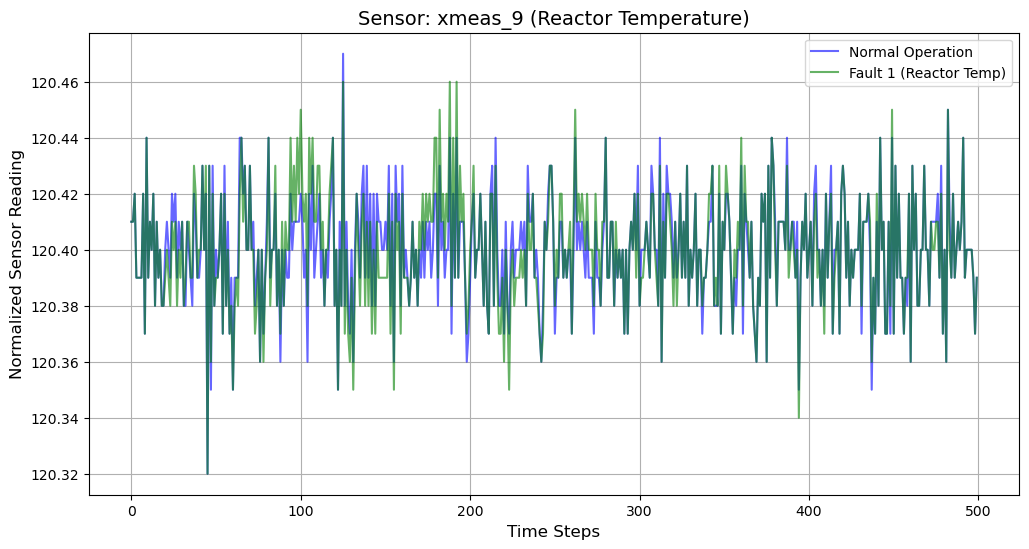

In [8]:
import matplotlib.pyplot as plt
# PLOT 1: The Reactor Temp (The Effect)
# SETTINGS
sensor_name = 'xmeas_9' 

rows_to_plot = 500       # How much data to see

# STEP 1: Get clean slices of data
# Get 500 rows of Normal Data
normal_data = df_normal[sensor_name].iloc[0:rows_to_plot].values

# Get 500 rows of Fault 1 Data
# We filter df_faulty to find rows where faultNumber is 1
fault_1_data = df_faulty[df_faulty['faultNumber'] == 1][sensor_name].iloc[0:rows_to_plot].values

# STEP 2: The Plot
plt.figure(figsize=(12, 6))

# Plot Normal (Blue)
plt.plot(normal_data, label='Normal Operation', color='blue', alpha=0.6)

# Plot Faulty (Red)
plt.plot(fault_1_data, label='Fault 1 (Reactor Temp)', color='green', alpha=0.6)

plt.title(f"Sensor: {sensor_name} (Reactor Temperature)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Normalized Sensor Reading", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

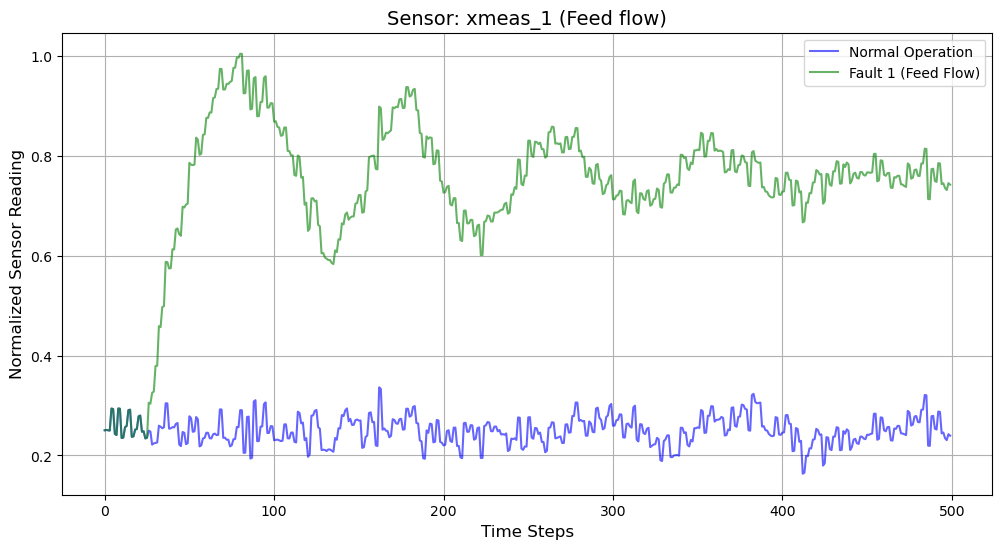

In [9]:

# SETTINGS
# PLOT 2: The Feed Flow (The Cause)
sensor_name = 'xmeas_1' 
''  #(Input Feed - A Feed Flow)
rows_to_plot = 500       # How much data to see

# STEP 1: Get clean slices of data
# Get 500 rows of Normal Data
normal_data = df_normal[sensor_name].iloc[0:rows_to_plot].values

# Get 500 rows of Fault 1 Data
# We filter df_faulty to find rows where faultNumber is 1
fault_1_data = df_faulty[df_faulty['faultNumber'] == 1][sensor_name].iloc[0:rows_to_plot].values

# STEP 2: The Plot
plt.figure(figsize=(12, 6))

# Plot Normal (Blue)
plt.plot(normal_data, label='Normal Operation', color='blue', alpha=0.6)

# Plot Faulty (Red)
plt.plot(fault_1_data, label='Fault 1 (Feed Flow)', color='green', alpha=0.6)

plt.title(f"Sensor: {sensor_name} (Feed flow)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Normalized Sensor Reading", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Compare the stats of the two sensors
cols_to_check = ['xmeas_1', 'xmeas_9']
print(df_faulty[cols_to_check].describe())

            xmeas_1       xmeas_9
count  5.000000e+06  5.000000e+06
mean   2.613588e-01  1.204002e+02
std    1.495384e-01  7.290890e-02
min   -4.735000e-03  1.196300e+02
25%    2.183000e-01  1.203800e+02
50%    2.511300e-01  1.204000e+02
75%    2.832100e-01  1.204200e+02
max    1.017500e+00  1.210100e+02


In [11]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
print("Fitting the scaler to normal data")
scaler.fit(df_normal.iloc[:,3:])
print("Transforming the faulty data")
X_faulty_scaled =scaler.transform(df_faulty.iloc[:,3:])
df_scaled_check = pd.DataFrame(X_faulty_scaled,columns=df_faulty.columns[3:])
print("New stats after scaling")
print(df_scaled_check[['xmeas_1','xmeas_9']].describe())

Fitting the scaler to normal data
Transforming the faulty data
New stats after scaling
            xmeas_1       xmeas_9
count  5.000000e+06  5.000000e+06
mean   3.522995e-01  7.881113e-03
std    4.843597e+00  3.815528e+00
min   -8.266564e+00 -4.029741e+01
25%   -1.042389e+00 -1.047797e+00
50%    2.098549e-02 -1.140855e-03
75%    1.060067e+00  1.045516e+00
max    2.484396e+01  3.192188e+01


In [12]:
import numpy as np
#getting original labels from the faulty dataframe
y_all=df_faulty['faultNumber'].values
#Selecting only rows where fault is 1 or 2,creasting a filter
filter_mask=(y_all==1)|(y_all==2)
#applying the filter to our scaler data(x) and labels(y)
X_final=X_faulty_scaled[filter_mask]
y_final=y_all[filter_mask]
print(f"final input shape(X):{X_final.shape}")
print(f"final target shape(y):{y_final.shape}")
print(f"faults included:{np.unique(y_final)}")


final input shape(X):(500000, 52)
final target shape(y):(500000,)
faults included:[1 2]


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
#data splitting,80-20
#stratify=y_final ensures we have equal amounts of Fault 1 and fault 2 in both sets
X_train,X_test,y_train,y_test=train_test_split(X_final,y_final,test_size=0.2,random_state=42,stratify=y_final)
print('Data successfully split.')
print(f'Training on{X_train.shape[0]}sample')
print(f'testing on{X_test.shape[0]}sample')
#initialising the model
#n_estimator=50 means build 50 trees
clf=RandomForestClassifier(n_estimators=50,random_state=42,n_jobs=-1)
#training the model
print("Training the model")
clf.fit(X_train,y_train)
#Predicion
print("Predicting on data")
y_pred=clf.predict(X_test)
#grade
accuracy=accuracy_score(y_test,y_pred)
print(f'Results')
print(f'Model accuracy:{accuracy:4f}({accuracy*100:2f}%)')

Data successfully split.
Training on400000sample
testing on100000sample
Training the model
Predicting on data
Results
Model accuracy:0.961800(96.180000%)


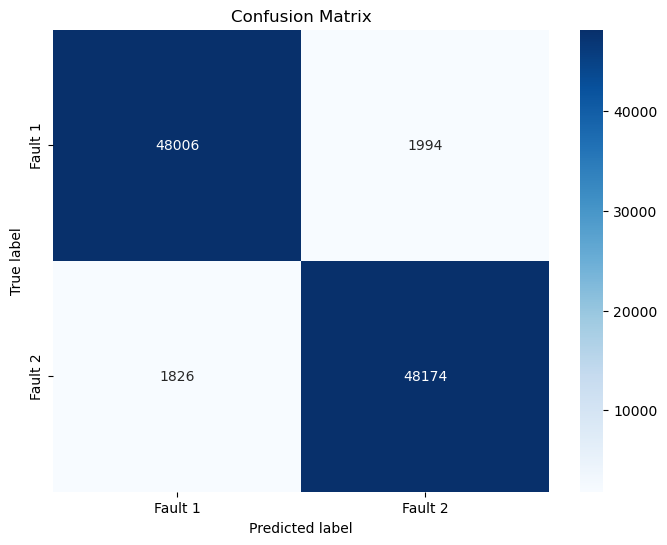

In [14]:
import seaborn as sns
#calculating the matrix
#this is comparing the answer key (y_test)vs our answer(y_pred)
cm=confusion_matrix(y_test,y_pred)
#plotting it as a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Fault 1','Fault 2'],
            yticklabels=['Fault 1','Fault 2'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()


In [15]:
#preparing the full data
#no masking , taking everything
X_big=X_faulty_scaled #the scaled sensors data,i.e. faults
y_big=df_faulty['faultNumber'].values #the labels(0 to 20)
print(f'training on all faults')
print(f'input shape:{X_big.shape}')
print(f'classes found:{np.unique(y_big)}')
# Downsample to 10% of the data to speed up training
X_big, _, y_big, _ = train_test_split(X_faulty_scaled, df_faulty['faultNumber'].values, train_size=0.1, stratify=df_faulty['faultNumber'].values, random_state=42)
print(f"Original Data Size: {X_faulty_scaled.shape[0]}")
print(f"New Training Data Size: {X_big.shape[0]} ")
#THE STANDARD SPLIT (80/20)
X_train_big,X_test_big,y_train_big,y_test_big=train_test_split(
    X_big,y_big,test_size=0.2,random_state=42,stratify=y_big
)
#training the bigmodel
#increasing n_estimators to 100
print("Training Random Forest on 20 classes")
clf_big = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42,verbose=2)
clf_big.fit(X_train_big, y_train_big)
#evaluate
print("Predicting")
y_pred_big = clf_big.predict(X_test_big)
acc = accuracy_score(y_test_big, y_pred_big)
print("MEGA-MODEL RESULTS")
print(f"Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Showing the score for every single fault
print("\nDetailed Report:")
print(classification_report(y_test_big, y_pred_big, digits=3))

training on all faults
input shape:(5000000, 52)
classes found:[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]
Original Data Size: 5000000
New Training Data Size: 500000 
Training Random Forest on 20 classes
building tree 1 of 100
building tree 2 of 100
building tree 3 of 100
building tree 4 of 100
building tree 5 of 100
building tree 6 of 100
building tree 7 of 100
building tree 8 of 100


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.


building tree 9 of 100
building tree 10 of 100
building tree 11 of 100
building tree 12 of 100
building tree 13 of 100
building tree 14 of 100
building tree 15 of 100
building tree 16 of 100
building tree 17 of 100
building tree 18 of 100
building tree 19 of 100
building tree 20 of 100
building tree 21 of 100
building tree 22 of 100
building tree 23 of 100
building tree 24 of 100
building tree 25 of 100
building tree 26 of 100
building tree 27 of 100
building tree 28 of 100
building tree 29 of 100
building tree 30 of 100
building tree 31 of 100
building tree 32 of 100
building tree 33 of 100


[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   55.5s


building tree 34 of 100
building tree 35 of 100
building tree 36 of 100
building tree 37 of 100
building tree 38 of 100
building tree 39 of 100
building tree 40 of 100
building tree 41 of 100
building tree 42 of 100
building tree 43 of 100
building tree 44 of 100
building tree 45 of 100
building tree 46 of 100
building tree 47 of 100
building tree 48 of 100
building tree 49 of 100
building tree 50 of 100
building tree 51 of 100
building tree 52 of 100
building tree 53 of 100
building tree 54 of 100
building tree 55 of 100
building tree 56 of 100
building tree 57 of 100
building tree 58 of 100
building tree 59 of 100
building tree 60 of 100
building tree 61 of 100
building tree 62 of 100
building tree 63 of 100
building tree 64 of 100
building tree 65 of 100
building tree 66 of 100
building tree 67 of 100
building tree 68 of 100
building tree 69 of 100
building tree 70 of 100
building tree 71 of 100
building tree 72 of 100
building tree 73 of 100
building tree 74 of 100
building tree 75

[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  2.9min finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.


Predicting


[Parallel(n_jobs=8)]: Done  25 tasks      | elapsed:    0.4s


MEGA-MODEL RESULTS
Accuracy: 0.7728 (77.28%)

Detailed Report:
              precision    recall  f1-score   support

           1      0.959     0.950     0.955      5000
           2      0.956     0.941     0.948      5000
           3      0.222     0.300     0.255      5000
           4      0.900     0.937     0.918      5000
           5      0.950     0.947     0.949      5000
           6      0.969     0.954     0.961      5000
           7      0.969     0.961     0.965      5000
           8      0.934     0.883     0.908      5000
           9      0.206     0.251     0.226      5000
          10      0.756     0.771     0.763      5000
          11      0.845     0.762     0.801      5000
          12      0.870     0.888     0.879      5000
          13      0.913     0.829     0.869      5000
          14      0.966     0.937     0.951      5000
          15      0.210     0.236     0.222      5000
          16      0.875     0.729     0.796      5000
          17      

[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    1.4s finished


In [34]:
# 1. Create a mask to ignore Faults 3, 9, and 15
# We keep everything where the True Label is NOT 3, 9, or 15
mask_observable = ~np.isin(y_test_big, [3, 9, 15])

# 2. Filter the answers and predictions
y_test_obs = y_test_big[mask_observable]
y_pred_obs = y_pred_big[mask_observable]

# 3. Recalculate Accuracy
new_acc = accuracy_score(y_test_obs, y_pred_obs)

print(f"ADJUSTED RESULTS ")
print(f"Original Accuracy (All Faults): {acc*100:.2f}%")
print(f"Observable Accuracy (No 3, 9, 15): {new_acc*100:.2f}%")

ADJUSTED RESULTS 
Original Accuracy (All Faults): 77.28%
Observable Accuracy (No 3, 9, 15): 86.29%


In [39]:
from xgboost import XGBClassifier


In [41]:
print("Training XGBoost (with Label Fix)")

# STEP 1: FIX THE LABELS (Shift down by 1)
# XGBoost wants 0-19, but we have 1-20.
# We create temporary variables for training.
y_train_shifted = y_train_big - 1
y_test_shifted = y_test_big - 1

# STEP 2: TRAIN
model_xgb = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    n_jobs=-1, 
    random_state=42
)

# Train on the 0-19 labels
model_xgb.fit(X_train_big, y_train_shifted)

#  STEP 3: PREDICT
# The model will output 0-19
y_pred_raw = model_xgb.predict(X_test_big)

# STEP 4: SHIFT BACK (Add 1)
# Convert 0-19 back to 1-20 so it matches our physics
y_pred_xgb = y_pred_raw + 1

# STEP 5: EVALUATE
# Now we compare "Apples to Apples" (1-20 vs 1-20)

# Create the mask to ignore faults 3, 9, 15
mask_obs = ~np.isin(y_test_big, [3, 9, 15])

# Calculate score
acc_xgb = accuracy_score(y_test_big[mask_obs], y_pred_xgb[mask_obs])

print(f"FINAL SCORECARD")
print(f"Random Forest Accuracy: 86.29%")
print(f"XGBoost Accuracy: {acc_xgb*100:.2f}%")

Training XGBoost (with Label Fix)
FINAL SCORECARD
Random Forest Accuracy: 86.29%
XGBoost Accuracy: 86.57%


Loading Faulty Data...
Loading Normal Data...


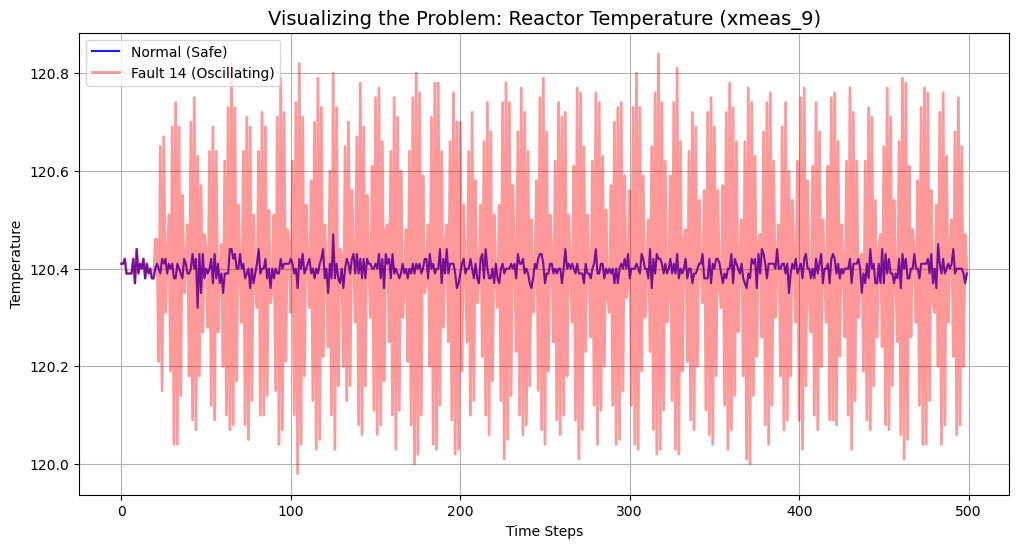

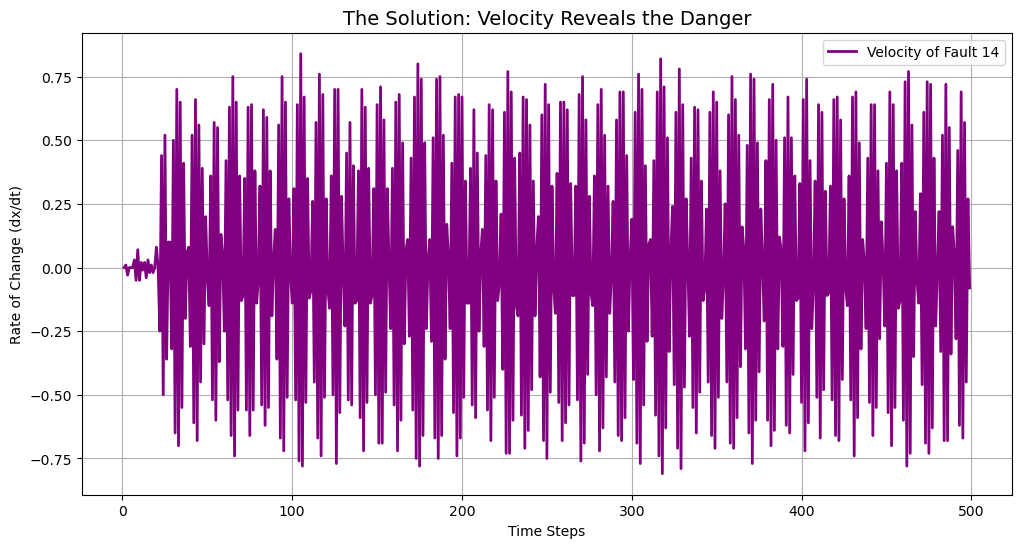

In [26]:


# 1. Load FAULTY Data (for Fault 14)
try:
    print("Loading Faulty Data...")
    result_faulty = pyreadr.read_r('TEP_Faulty_Training.RData')
    df_faulty = result_faulty[list(result_faulty.keys())[0]]
except Exception as e:
    print(f"Error loading faulty data: {e}")

# 2. Load NORMAL Data (for the Blue Line)
try:
    print("Loading Normal Data...")
    result_normal = pyreadr.read_r('TEP_FaultFree_Training.RData')
    df_normal = result_normal[list(result_normal.keys())[0]]
except Exception as e:
    print(f"Error loading normal data: {e}")

# 3. Select Data Slices
# Fault 14: Reactor Cooling Valve Sticking
fault_14_data = df_faulty[df_faulty['faultNumber'] == 14]['xmeas_9'].iloc[:500].values
# Normal: Steady State
normal_data = df_normal['xmeas_9'].iloc[:500].values 

# 4. PLOT 1: The Temperature (Position)
plt.figure(figsize=(12, 6))
plt.plot(normal_data, label='Normal (Safe)', color='blue', alpha=0.9)
plt.plot(fault_14_data, label='Fault 14 (Oscillating)', color='red', linewidth=2,alpha=0.4)

plt.title("Visualizing the Problem: Reactor Temperature (xmeas_9)", fontsize=14)
plt.ylabel("Temperature")
plt.xlabel("Time Steps")
plt.legend()
plt.grid(True)
plt.show()

# 5. PLOT 2: The Velocity (Rate of Change)
# This is the "Aha!" moment.
plt.figure(figsize=(12, 6))

# Calculate Velocity for Fault 14
velocity_signal = pd.Series(fault_14_data).diff()

plt.plot(velocity_signal, label='Velocity of Fault 14', color='purple', linewidth=2)
plt.title("The Solution: Velocity Reveals the Danger", fontsize=14)
plt.ylabel("Rate of Change (dx/dt)")
plt.xlabel("Time Steps")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import pandas as pd
import numpy as np
import gc # Garbage collector
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

print("SYSTEM REBOOTED: STARTING FRESH")

# PHASE 1: LOAD DATA (WE NEED TO RELOAD SINCE RESTART WIPED IT)
# UPDATE THIS PATH TO YOUR ACTUAL FILE LOCATION!
# If the file is in the same folder, just use the filename.
try:
    # Try reading directly (if you saved it as CSV earlier)
    # If you are still using the RData file, we need pyreadr
    import pyreadr
    print("Loading Raw Data")
    result_faulty = pyreadr.read_r('TEP_Faulty_Training.RData')
    df_faulty = result_faulty[list(result_faulty.keys())[0]]
except:
    print("Error loading data. Make sure TEP_Faulty_Training.RData is in the folder.")

# PHASE 2: OPTIMIZED FEATURE ENGINEERING (Low RAM)
print("Calculating Velocity")
sensor_cols = df_faulty.columns[3:]
# Calculate velocity on the full dataset (Physics requirement)
df_velocity = df_faulty[sensor_cols].diff().fillna(0)

print("Generating 10% Indices")
indices = np.arange(len(df_faulty))
# Split indices instead of data (Saves RAM)
idx_keep, _ = train_test_split(
    indices, 
    train_size=0.1, 
    stratify=df_faulty['faultNumber'].values, 
    random_state=42
)

print("Slicing Data")
# Reconstruct the small dataset
X_small_sensors = df_faulty[sensor_cols].iloc[idx_keep]
X_small_velocity = df_velocity.iloc[idx_keep]
y_small_dyn = df_faulty['faultNumber'].iloc[idx_keep].values

# Cleaning RAM
print("Cleaning RAM")
del df_faulty
del df_velocity
del result_faulty
gc.collect()

print("Combining & Scaling")
X_small_dyn_raw = pd.concat([X_small_sensors, X_small_velocity], axis=1)
scaler_dyn = StandardScaler()
X_small_dyn_scaled = scaler_dyn.fit_transform(X_small_dyn_raw)

# PHASE 3: TRAIN XGBOOST
print("Splitting Train/Test (80/20)")
X_train_dyn, X_test_dyn, y_train_dyn, y_test_dyn = train_test_split(
    X_small_dyn_scaled, 
    y_small_dyn, 
    test_size=0.2, 
    stratify=y_small_dyn, 
    random_state=42
)

print("Training XGBoost (100 Trees)")
model_dyn = XGBClassifier(n_estimators=100, learning_rate=0.1, n_jobs=-1, random_state=42)
# Shift labels 1-20 -> 0-19
model_dyn.fit(X_train_dyn, y_train_dyn - 1)

# PHASE 4: EVALUATE
print("Predicting")
y_pred_dyn = model_dyn.predict(X_test_dyn) + 1 # Shift back

# Filter Observable Faults (No 3, 9, 15)
mask_obs = ~np.isin(y_test_dyn, [3, 9, 15])
acc_dyn = accuracy_score(y_test_dyn[mask_obs], y_pred_dyn[mask_obs])

print(f"Final velocity enhanced accuracy: {acc_dyn*100:.2f}%")


SYSTEM REBOOTED: STARTING FRESH
Loading Raw Data...
Calculating Velocity...
Generating 10% Indices...
Slicing Data
Cleaning RAM
Combining & Scaling...
Splitting Train/Test (80/20)...
Training XGBoost (100 Trees)
Predicting
Final velocity enhanced accuracy: 88.16%


Generating Feature Map


<Figure size 1000x800 with 0 Axes>

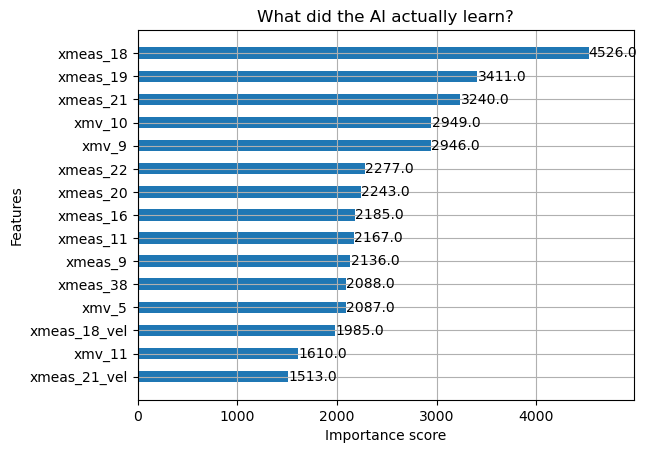

In [3]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

print("Generating Feature Map")

# 1. Get the names from the Small Dataset (which still exists in memory)
# The first 52 columns are the Sensors
sensor_names = list(X_small_dyn_raw.columns[:52])

# 2. Create the Velocity names manually
# The second 52 columns correspond to these, but with "_vel" added
velocity_names = [f"{col}_vel" for col in sensor_names]

# 3. Combining them
all_feature_names = sensor_names + velocity_names

# 4. Assigning to model
model_dyn.get_booster().feature_names = all_feature_names

# 5. Plot
plt.figure(figsize=(10, 8))
plot_importance(model_dyn, max_num_features=15, height=0.5, importance_type='weight', title='What did the AI actually learn?')
plt.show()

In [6]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import numpy as np

print("LIGHTWEIGHT TUNING")

# 1. Define the Shifted Labels (If not already defined)
y_train_shifted = y_train_dyn - 1

# 2. Create the "Tuning Slice" (10% of training data)
X_tune, _, y_tune, _ = train_test_split(
    X_train_dyn, 
    y_train_shifted, 
    train_size=0.1,  
    stratify=y_train_shifted, 
    random_state=42
)

# 3. Define a "Lighter" Menu (Removed Depth 9 and 200 Trees)
param_grid = {
    'n_estimators': [50, 100],      # Reduced from [100, 200]
    'learning_rate': [0.1, 0.2],    # Focused on standard rates
    'max_depth': [3, 6],            # Removed 9 (Exponentially expensive)
    'subsample': [0.8, 1.0]
}

# 4. Run Search with HIGHER VERBOSITY
# verbose=3 will print every single step so you know it's not frozen
random_search = RandomizedSearchCV(
    estimator=XGBClassifier(n_jobs=-1, random_state=42),
    param_distributions=param_grid,
    n_iter=6,      # Test 6 combinations (Enough to find a good one)
    scoring='accuracy',
    cv=3,
    verbose=3,     # TALKATIVE MODE
    random_state=42
)

print("Starting Search (Watch the log below)")
random_search.fit(X_tune, y_tune)

print(f"\nBest Parameters Found: {random_search.best_params_}")

# 5. Apply the Best Settings to the BIG Model (Full Training Data)
print("\nTraining Final Model with Best Parameters")
best_model = XGBClassifier(
    **random_search.best_params_, 
    n_jobs=-1, 
    random_state=42
)

best_model.fit(X_train_dyn, y_train_shifted)

# 6. Evaluate
y_pred_tuned = best_model.predict(X_test_dyn) + 1 # Shift back
mask_obs = ~np.isin(y_test_dyn, [3, 9, 15])
acc_tuned = accuracy_score(y_test_dyn[mask_obs], y_pred_tuned[mask_obs])

print(f"OPTIMIZED FINAL ACCURACY ")
print(f"Before Tuning: 88.16%")
print(f"After Tuning:  {acc_tuned*100:.2f}%")

LIGHTWEIGHT TUNING (RESTARTED)
Starting Search (Watch the log below)
Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV 1/3] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.740 total time=   4.4s
[CV 2/3] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.739 total time=   4.8s
[CV 3/3] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=0.8;, score=0.734 total time=   4.6s
[CV 1/3] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1.0;, score=0.742 total time=   4.3s
[CV 2/3] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1.0;, score=0.739 total time=   3.9s
[CV 3/3] END learning_rate=0.1, max_depth=3, n_estimators=50, subsample=1.0;, score=0.732 total time=   3.9s
[CV 1/3] END learning_rate=0.1, max_depth=6, n_estimators=50, subsample=1.0;, score=0.774 total time=   8.5s
[CV 2/3] END learning_rate=0.1, max_depth=6, n_estimators=50, subsample=1.0;, score=0.773 total time=   8.3s

In [7]:
import joblib
import os

print("PACKING THE SUITCASE")

# 1. Define filenames
model_filename = 'tep_xgboost_model.pkl'
scaler_filename = 'tep_scaler.pkl'

# 2. Save the Model (The Brain)
# We assume 'best_model' is the name of your final tuned XGBoost model
# If you didn't run tuning, use 'model_dyn' instead.
joblib.dump(best_model, model_filename)
print(f" Model saved to: {model_filename}")

# 3. Save the Scaler (The Translator)
joblib.dump(scaler_dyn, scaler_filename)
print(f"Scaler saved to: {scaler_filename}")

# 4. Verification Check
print("\nVerifying files on disk")
files = os.listdir()
if model_filename in files and scaler_filename in files:
    print("SUCCESS: Both files are ready for the app.")
else:
    print("ERROR: Something went wrong. Files not found.")

PACKING THE SUITCASE
 Model saved to: tep_xgboost_model.pkl
Scaler saved to: tep_scaler.pkl

Verifying files on disk
SUCCESS: Both files are ready for the app.


Coding ended, now its presentation

In [9]:
#Project 
import pandas as pd

print("Generating Test CSV...")

# 1. Take the first 100 rows and first 52 columns (Sensors)
# X_small_dyn_raw is already a DataFrame, so we can slice it directly.
df_test_sample = X_small_dyn_raw.iloc[:100, :52]

# 2. Save to CSV
df_test_sample.to_csv("test_sensors.csv", index=False)

print(" SUCCESS: 'test_sensors.csv' created.")

Generating Test CSV...
 SUCCESS: 'test_sensors.csv' created.


The App Code

In [10]:
%%writefile dashboard.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

#  PAGE CONFIG 
st.set_page_config(page_title="TEP AI Diagnosis", page_icon="🏭", layout="wide")

# 1. LOAD THE BRAIN
@st.cache_resource
def load_assets():
    try:
        model = joblib.load('tep_xgboost_model.pkl')
        scaler = joblib.load('tep_scaler.pkl')
        return model, scaler
    except FileNotFoundError:
        return None, None

model, scaler = load_assets()

# 2. SIDEBAR
st.sidebar.title("Control Room")
st.sidebar.info("Status: System Online")

# 3. MAIN INTERFACE
st.title("Chemical Process Fault Diagnosis")
st.markdown("Upload raw sensor data to detect Reactor & Separator faults.")

if model is None:
    st.error(" ERROR: .pkl files not found. Make sure they are in the same folder!")
    st.stop()

#  4. DATA UPLOAD 
uploaded_file = st.file_uploader("Upload Sensor CSV (52 Columns)", type=["csv"])

if uploaded_file is not None:
    try:
        df_input = pd.read_csv(uploaded_file)
        
        # 5. FEATURE ENGINEERING
        # A. Calculate Velocity
        df_velocity = df_input.iloc[:, :52].diff().fillna(0)
        
        # B. Combine
        X_combined = pd.concat([df_input.iloc[:, :52], df_velocity], axis=1)
        
        # C. Scale
        X_scaled = scaler.transform(X_combined)
        
        # D. Predict (Shift 0-19 back to 1-20)
        preds_human = model.predict(X_scaled) + 1
        
        # 6. RESULTS
        st.subheader("Diagnostic Results")
        
        col1, col2 = st.columns(2)
        with col1:
            st.metric("Latest Fault Detected", f"Fault {preds_human[-1]}")
        with col2:
            st.metric("Rows Processed", len(df_input))

        st.line_chart(preds_human)
        
        df_results = df_input.copy()
        df_results['AI_Diagnosis'] = preds_human
        st.dataframe(df_results)

    except Exception as e:
        st.error(f"Processing Error: {e}")

Writing dashboard.py


--- FULL RECOVERY MODE ---
Loading Model...
✓ Model Loaded.
Reading RData file (Wait ~20s)...
Calculating Velocity...
Reconstructing Test Set...
✓ Data Restored Successfully.

--- CALCULATING ROC CURVE ---
Target: Fault 14 (Sticking Valve)
AUC Score: 0.9987
EER Score: 0.0225


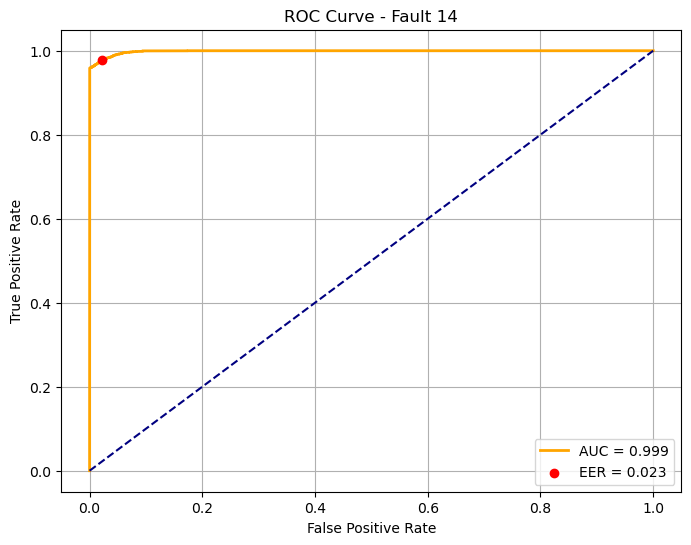

In [5]:
import pandas as pd
import numpy as np
import joblib
import pyreadr
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

print("--- FULL RECOVERY MODE ---")

# 1. Load the "Brain" (Model)
try:
    print("Loading Model...")
    best_model = joblib.load('tep_xgboost_model.pkl')
    scaler = joblib.load('tep_scaler.pkl')
    print("✓ Model Loaded.")
except:
    print("❌ CRITICAL ERROR: .pkl files missing. You might need to retrain.")

# 2. Reload the Raw Data (The "Body")
# We MUST do this to recreate y_test_dyn
try:
    print("Reading RData file (Wait ~20s)...")
    result = pyreadr.read_r('TEP_Faulty_Training.RData')
    df_faulty = result[list(result.keys())[0]]
    
    # 3. Re-do the Engineering (Velocity)
    print("Calculating Velocity...")
    sensor_cols = df_faulty.columns[3:]
    df_velocity = df_faulty[sensor_cols].diff().fillna(0)
    
    # 4. Re-do the Split (Exact same random_state=42)
    print("Reconstructing Test Set...")
    indices = np.arange(len(df_faulty))
    idx_keep, _ = train_test_split(indices, train_size=0.1, stratify=df_faulty['faultNumber'], random_state=42)
    
    # Slice the data
    X_small_sensors = df_faulty[sensor_cols].iloc[idx_keep]
    X_small_velocity = df_velocity.iloc[idx_keep]
    y_small_dyn = df_faulty['faultNumber'].iloc[idx_keep].values
    
    # Scale
    X_raw = pd.concat([X_small_sensors, X_small_velocity], axis=1)
    X_scaled = scaler.transform(X_raw)
    
    # Final Split (80/20) to get the Test Set
    _, X_test_dyn, _, y_test_dyn = train_test_split(
        X_scaled, y_small_dyn, test_size=0.2, stratify=y_small_dyn, random_state=42
    )
    print("✓ Data Restored Successfully.")

except Exception as e:
    print(f"❌ Error loading data: {e}")

# 5. Calculate ROC/AUC (The Senior Engineer's Request)
print("\n--- CALCULATING ROC CURVE ---")
target_fault = 14
print(f"Target: Fault {target_fault} (Sticking Valve)")

# Binary Labels (1 = Fault 14, 0 = Everything else)
y_test_binary = (y_test_dyn == target_fault).astype(int)

# Get Probabilities
y_prob = best_model.predict_proba(X_test_dyn)
y_prob_target = y_prob[:, target_fault - 1] # -1 because array is 0-19

# Calculate Metrics
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob_target)
roc_auc = auc(fpr, tpr)

# Calculate EER
fnr = 1 - tpr
eer_idx = np.nanargmin(np.absolute((fnr - fpr)))
eer = fpr[eer_idx]

print(f"AUC Score: {roc_auc:.4f}")
print(f"EER Score: {eer:.4f}")

# Plot
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='orange', lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.scatter([eer], [1-eer], color='red', label=f'EER = {eer:.3f}', zorder=5)
plt.title(f'ROC Curve - Fault {target_fault}')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()